### 1. Σύνδεση με το Google Drive & Φόρτωση Δεδομένων


In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Η αποσυμπίεση ολοκληρώθηκε!")
else:
    print("Τα δεδομένα είναι ήδη αποσυμπιεσμένα!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Τα δεδομένα είναι ήδη αποσυμπιεσμένα!


### 2. Προεπεξεργασία

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

DATA_PATH = '/content/dataset/dataset2-master/dataset2-master/images/TRAIN'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
medical_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=1.0),

    layers.RandomContrast(factor=0.3),
    layers.RandomBrightness(factor=0.2),

], name="medical_augmentation_pipeline")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)



Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.


### 3. MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

def build_mobilenet_model(learning_rate=0.001, dropout_rate=0.2, optimizer_choice='adam'):

    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Παγώνουμε τα βάρη

    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = medical_augmentation(inputs)
    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

### 4. MobileNetV2 (Grid Search Hyperparameter Tuning)

ΠΕΙΡΑΜΑ 1/8: ADAM | LR:0.001 | Drop:0.2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.4902 - loss: 1.1760 - val_accuracy: 0.6539 - val_loss: 0.8996
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.6160 - loss: 0.9235 - val_accuracy: 0.6720 - val_loss: 0.8151
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6528 - loss: 0.8375 - val_accuracy: 0.7263 - val_loss: 0.7384
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6778 - loss: 0.7885 - val_accuracy: 0.7338 - val_loss: 0.7105
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6729 - loss: 0.7859 - val_accuracy: 0.7072 - val_loss: 0.7400
Restoring model weights from the end of the best epoch: 4.
ΠΕΙΡΑΜΑ 2/8: ADAM | LR:0.001 | Drop:0.5
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.4045 - loss: 1.4520 - val_accuracy: 0.6364 - val_loss: 0.9449
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━

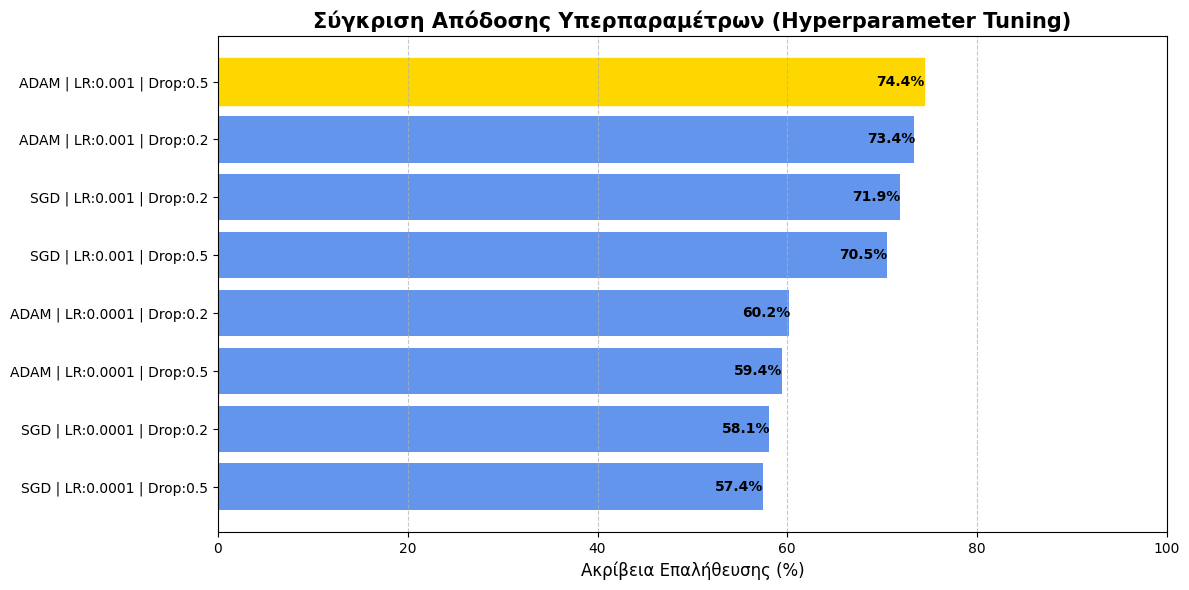

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [0.001, 0.0001]
optimizers_opts = ['adam', 'sgd']
dropouts = [0.2, 0.5]

EPOCHS = 5

results_acc = {}
best_acc = 0.0
best_combo_name = ""

combo_num = 1
for lr in learning_rates:
    for opt in optimizers_opts:
        for drop in dropouts:
            combo_name = f"{opt.upper()} | LR:{lr} | Drop:{drop}"
            print(f"ΠΕΙΡΑΜΑ {combo_num}/8: {combo_name}")

            early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

            model = build_mobilenet_model(learning_rate=lr, dropout_rate=drop, optimizer_choice=opt)

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=[early_stop],
                verbose=1
            )

            val_acc = max(history.history['val_accuracy']) * 100
            results_acc[combo_name] = val_acc

            if val_acc > best_acc:
                best_acc = val_acc
                best_combo_name = combo_name

            combo_num += 1

print(f"\nΟ Καλύτερος Συνδυασμός: {best_combo_name} με {best_acc:.1f}%")

plt.figure(figsize=(12, 6))
sorted_results = dict(sorted(results_acc.items(), key=lambda item: item[1]))

bars = plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color='cornflowerblue')
bars[-1].set_color('gold')

plt.title('Σύγκριση Απόδοσης Υπερπαραμέτρων (Hyperparameter Tuning)', fontsize=15, fontweight='bold')
plt.xlabel('Ακρίβεια Επαλήθευσης (%)', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval - 5, bar.get_y() + bar.get_height()/2, f'{xval:.1f}%',
             va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

### 6. ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

def build_resnet_model(learning_rate=0.001, dropout_rate=0.2, optimizer_choice='adam'):

    base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    preprocess_input = tf.keras.applications.resnet50.preprocess_input

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = medical_augmentation(inputs)
    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

### 7. ResNet50 (Grid Search Hyperparameter Tuning)

RESNET ΠΕΙΡΑΜΑ 1/8: ADAM | LR:0.001 | Drop:0.2
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 55s 185ms/step - accuracy: 0.4468 - loss: 1.2891 - val_accuracy: 0.6439 - val_loss: 0.8921
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.5834 - loss: 0.9823 - val_accuracy: 0.6926 - val_loss: 0.7840
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.6214 - loss: 0.9056 - val_accuracy: 0.7408 - val_loss: 0.6929
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.6623 - loss: 0.8278 - val_accuracy: 0.7418 - val_loss: 0.6688
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 41s 166ms/step - accuracy: 0.6741 - loss: 0.7924 - val_accuracy: 0.7182 - val_loss: 0.6949
Restoring model weights from the end of the best epoch: 4.
RESNET ΠΕΙΡΑΜΑ 2/8: ADAM | LR:0.001 | Drop:0.5
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 52s 179ms/step - accuracy: 0.3979 - loss: 1.5385 - val_accuracy: 0.5917 - val_loss: 0.9688
Epoch 2/5
249/24

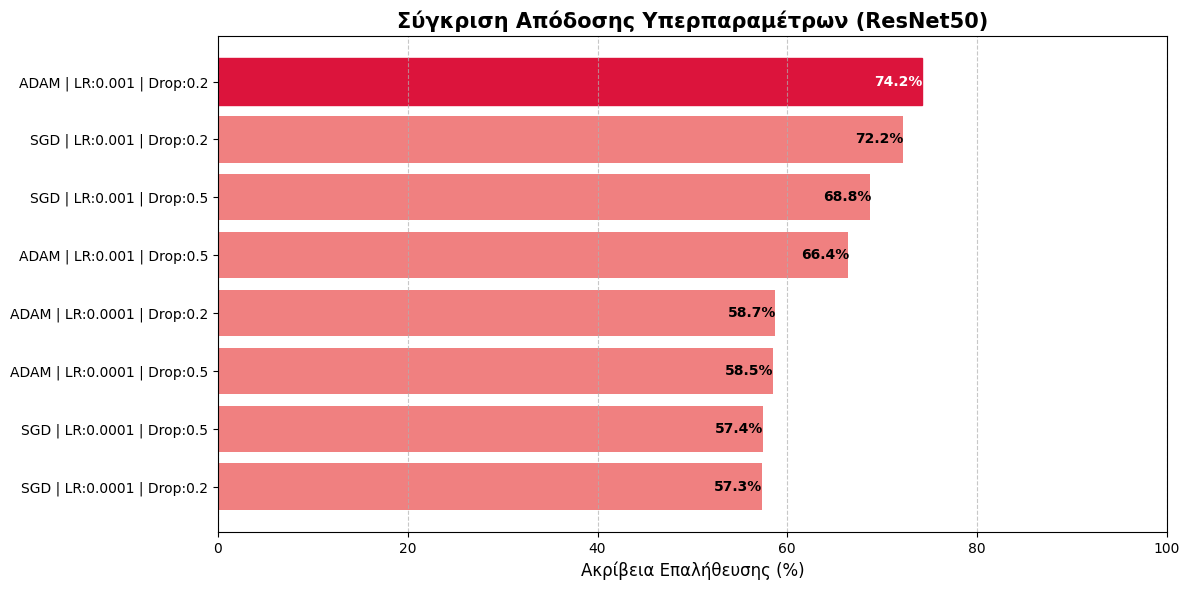

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [0.001, 0.0001]
optimizers_opts = ['adam', 'sgd']
dropouts = [0.2, 0.5]

EPOCHS = 5

results_acc_resnet = {}
best_acc_resnet = 0.0
best_combo_name_resnet = ""

combo_num = 1
for lr in learning_rates:
    for opt in optimizers_opts:
        for drop in dropouts:
            combo_name = f"{opt.upper()} | LR:{lr} | Drop:{drop}"
            print(f"RESNET ΠΕΙΡΑΜΑ {combo_num}/8: {combo_name}")

            early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

            model = build_resnet_model(learning_rate=lr, dropout_rate=drop, optimizer_choice=opt)

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=[early_stop],
                verbose=1
            )

            val_acc = max(history.history['val_accuracy']) * 100
            results_acc_resnet[combo_name] = val_acc

            if val_acc > best_acc_resnet:
                best_acc_resnet = val_acc
                best_combo_name_resnet = combo_name

            combo_num += 1

print(f"\nΟ Καλύτερος Συνδυασμός για το ResNet50: {best_combo_name_resnet} με {best_acc_resnet:.1f}%")

plt.figure(figsize=(12, 6))

sorted_results_resnet = dict(sorted(results_acc_resnet.items(), key=lambda item: item[1]))

bars = plt.barh(list(sorted_results_resnet.keys()), list(sorted_results_resnet.values()), color='lightcoral')
bars[-1].set_color('crimson')

plt.title('Σύγκριση Απόδοσης Υπερπαραμέτρων (ResNet50)', fontsize=15, fontweight='bold')
plt.xlabel('Ακρίβεια Επαλήθευσης (%)', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval - 5, bar.get_y() + bar.get_height()/2, f'{xval:.1f}%',
             va='center', color='white' if xval == bars[-1].get_width() else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

### 9. EfficientNetB0

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

def build_efficientnet_model(learning_rate=0.001, dropout_rate=0.2, optimizer_choice='adam'):

    base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    preprocess_input = tf.keras.applications.efficientnet.preprocess_input

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = medical_augmentation(inputs)
    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

### 10. EfficientNetB0 (Grid Search Hyperparameter Tuning )

EFFICIENTNET ΠΕΙΡΑΜΑ 1/8: ADAM | LR:0.001 | Drop:0.2
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 56s 103ms/step - accuracy: 0.4881 - loss: 1.1659 - val_accuracy: 0.6700 - val_loss: 0.9373
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.6167 - loss: 0.9445 - val_accuracy: 0.7107 - val_loss: 0.7890
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.6494 - loss: 0.8746 - val_accuracy: 0.7343 - val_loss: 0.7267
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6751 - loss: 0.8193 - val_accuracy: 0.7659 - val_loss: 0.6864
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.6880 - loss: 0.7761 - val_accuracy: 0.8016 - val_loss: 0.6206
Restoring model weights from the end of the best epoch: 5.
EFFICIENTNET ΠΕΙΡΑΜΑ 2/8: ADAM | LR:0.001 | Drop:0.5
Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step - accuracy: 0.4189 - loss: 1.2674 - val_accuracy: 0.6590 - val_loss: 0.9787
Epoch 2/

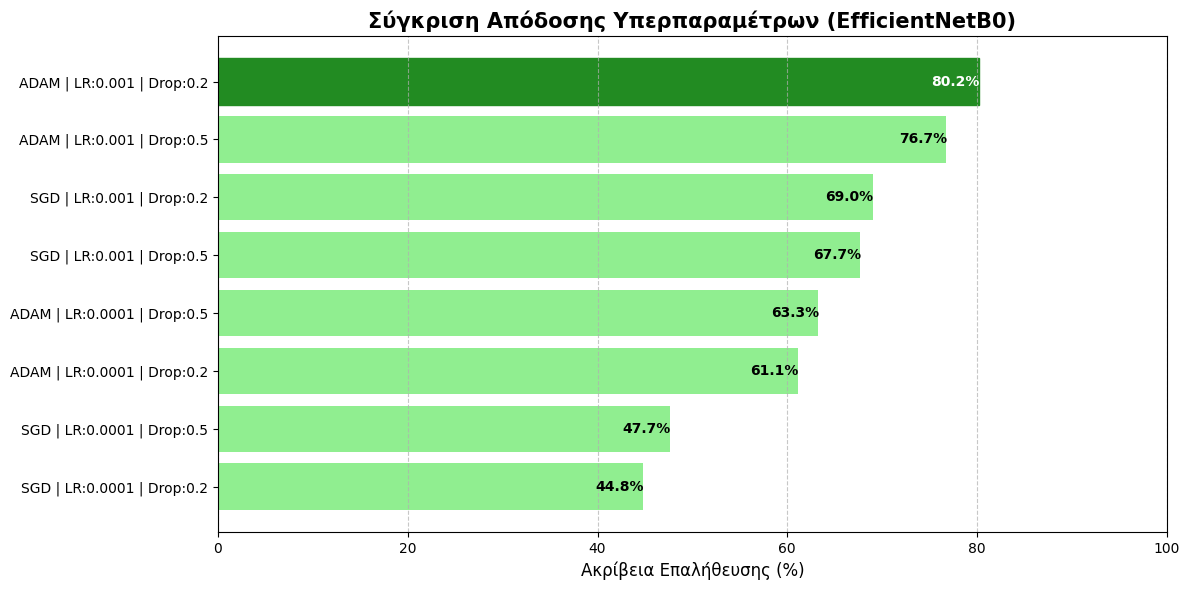

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [0.001, 0.0001]
optimizers_opts = ['adam', 'sgd']
dropouts = [0.2, 0.5]

EPOCHS = 5

results_acc_eff = {}
best_acc_eff = 0.0
best_combo_name_eff = ""

combo_num = 1
for lr in learning_rates:
    for opt in optimizers_opts:
        for drop in dropouts:
            combo_name = f"{opt.upper()} | LR:{lr} | Drop:{drop}"
            print(f"EFFICIENTNET ΠΕΙΡΑΜΑ {combo_num}/8: {combo_name}")

            early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

            model = build_efficientnet_model(learning_rate=lr, dropout_rate=drop, optimizer_choice=opt)

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=[early_stop],
                verbose=1
            )

            val_acc = max(history.history['val_accuracy']) * 100
            results_acc_eff[combo_name] = val_acc

            if val_acc > best_acc_eff:
                best_acc_eff = val_acc
                best_combo_name_eff = combo_name

            combo_num += 1

print(f"\nΟ Καλύτερος Συνδυασμός για το EfficientNetB0: {best_combo_name_eff} με {best_acc_eff:.1f}%")

plt.figure(figsize=(12, 6))

sorted_results_eff = dict(sorted(results_acc_eff.items(), key=lambda item: item[1]))

bars = plt.barh(list(sorted_results_eff.keys()), list(sorted_results_eff.values()), color='lightgreen')
bars[-1].set_color('forestgreen')

plt.title('Σύγκριση Απόδοσης Υπερπαραμέτρων (EfficientNetB0)', fontsize=15, fontweight='bold')
plt.xlabel('Ακρίβεια Επαλήθευσης (%)', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval - 5, bar.get_y() + bar.get_height()/2, f'{xval:.1f}%',
             va='center', color='white' if xval == bars[-1].get_width() else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

### 12. Metrics

Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - accuracy: 0.4851 - loss: 1.1798 - val_accuracy: 0.6384 - val_loss: 0.8985
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6061 - loss: 0.9289 - val_accuracy: 0.6730 - val_loss: 0.8191
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.6574 - loss: 0.8420 - val_accuracy: 0.7238 - val_loss: 0.7417
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.6668 - loss: 0.8068 - val_accuracy: 0.7157 - val_loss: 0.7351
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.6894 - loss: 0.7580 - val_accuracy: 0.7569 - val_loss: 0.6732
Epoch 6/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.7027 - loss: 0.7429 - val_accuracy: 0.7519 - val_loss: 0.6611
Epoch 7/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.7029 - loss: 0.7366 - val_accuracy: 0.7614 - val_loss: 0.6542
Epoch 8/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.7055 - loss: 0.7257 - 

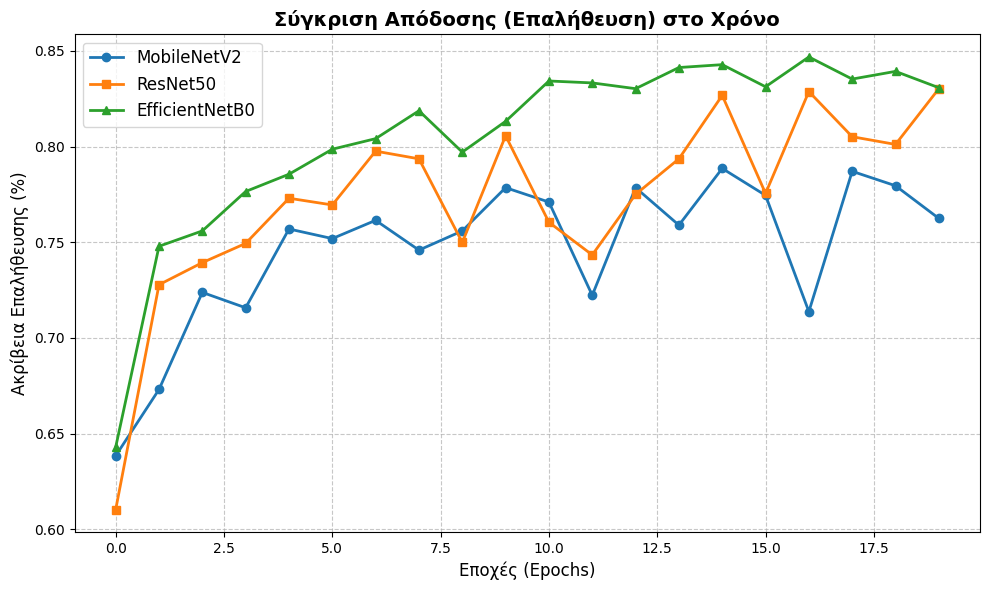


ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:
- MobileNetV2: 78.85%
- ResNet50: 83.02%
- EfficientNetB0: 84.68%


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

BEST_LR = 0.001
BEST_DROP = 0.2
BEST_OPT = 'adam'
MAX_EPOCHS = 20

tf.keras.backend.clear_session()
stopper_mobile = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
final_mobile = build_mobilenet_model(learning_rate=BEST_LR, dropout_rate=BEST_DROP, optimizer_choice=BEST_OPT)
hist_mobile = final_mobile.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, callbacks=[stopper_mobile], verbose=1)

tf.keras.backend.clear_session()
stopper_resnet = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
final_resnet = build_resnet_model(learning_rate=BEST_LR, dropout_rate=BEST_DROP, optimizer_choice=BEST_OPT)
hist_resnet = final_resnet.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, callbacks=[stopper_resnet], verbose=1)

tf.keras.backend.clear_session()
stopper_eff = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
final_eff = build_efficientnet_model(learning_rate=BEST_LR, dropout_rate=BEST_DROP, optimizer_choice=BEST_OPT)
hist_eff = final_eff.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, callbacks=[stopper_eff], verbose=1)

plt.figure(figsize=(10, 6))
plt.plot(hist_mobile.history['val_accuracy'], label='MobileNetV2', linewidth=2, marker='o')
plt.plot(hist_resnet.history['val_accuracy'], label='ResNet50', linewidth=2, marker='s')
plt.plot(hist_eff.history['val_accuracy'], label='EfficientNetB0', linewidth=2, marker='^')

plt.title('Σύγκριση Απόδοσης (Επαλήθευση) στο Χρόνο', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές (Epochs)', fontsize=12)
plt.ylabel('Ακρίβεια Επαλήθευσης (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\nΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:")
print(f"- MobileNetV2: {max(hist_mobile.history['val_accuracy'])*100:.2f}%")
print(f"- ResNet50: {max(hist_resnet.history['val_accuracy'])*100:.2f}%")
print(f"- EfficientNetB0: {max(hist_eff.history['val_accuracy'])*100:.2f}%")

### 13. Val Loss

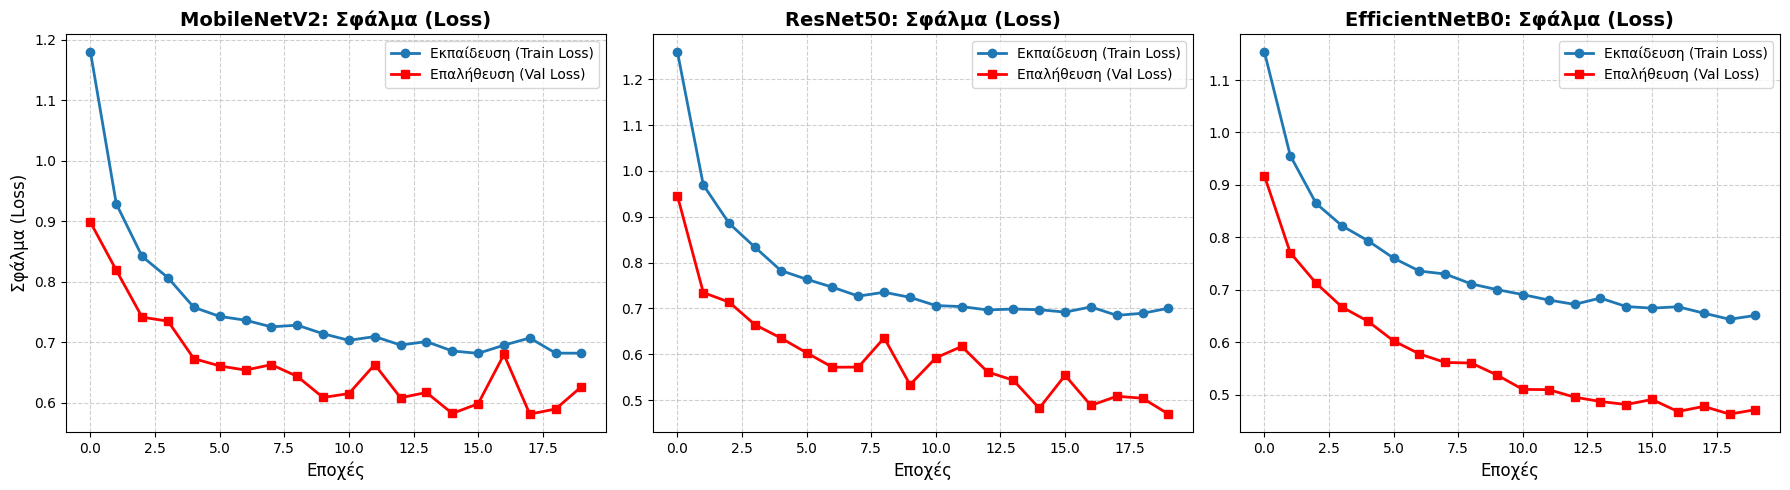

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_mobile.history['loss'], label='Εκπαίδευση (Train Loss)', linewidth=2, marker='o')
plt.plot(hist_mobile.history['val_loss'], label='Επαλήθευση (Val Loss)', linewidth=2, marker='s', color='red')
plt.title('MobileNetV2: Σφάλμα (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές', fontsize=12)
plt.ylabel('Σφάλμα (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist_resnet.history['loss'], label='Εκπαίδευση (Train Loss)', linewidth=2, marker='o')
plt.plot(hist_resnet.history['val_loss'], label='Επαλήθευση (Val Loss)', linewidth=2, marker='s', color='red')
plt.title('ResNet50: Σφάλμα (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist_eff.history['loss'], label='Εκπαίδευση (Train Loss)', linewidth=2, marker='o')
plt.plot(hist_eff.history['val_loss'], label='Επαλήθευση (Val Loss)', linewidth=2, marker='s', color='red')
plt.title('EfficientNetB0: Σφάλμα (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### 14. EfficientNetB0 (ROC & Sample)

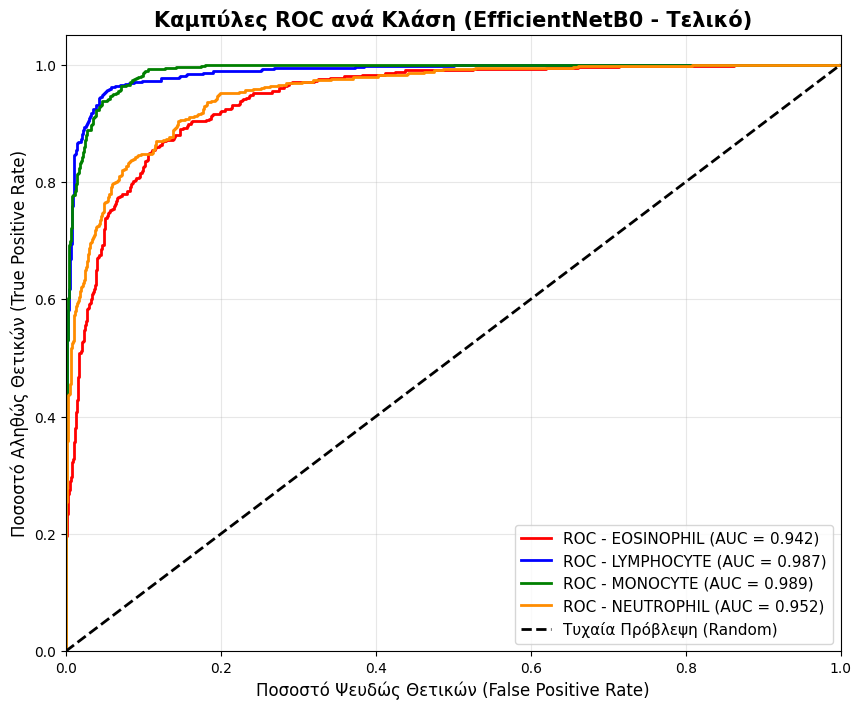

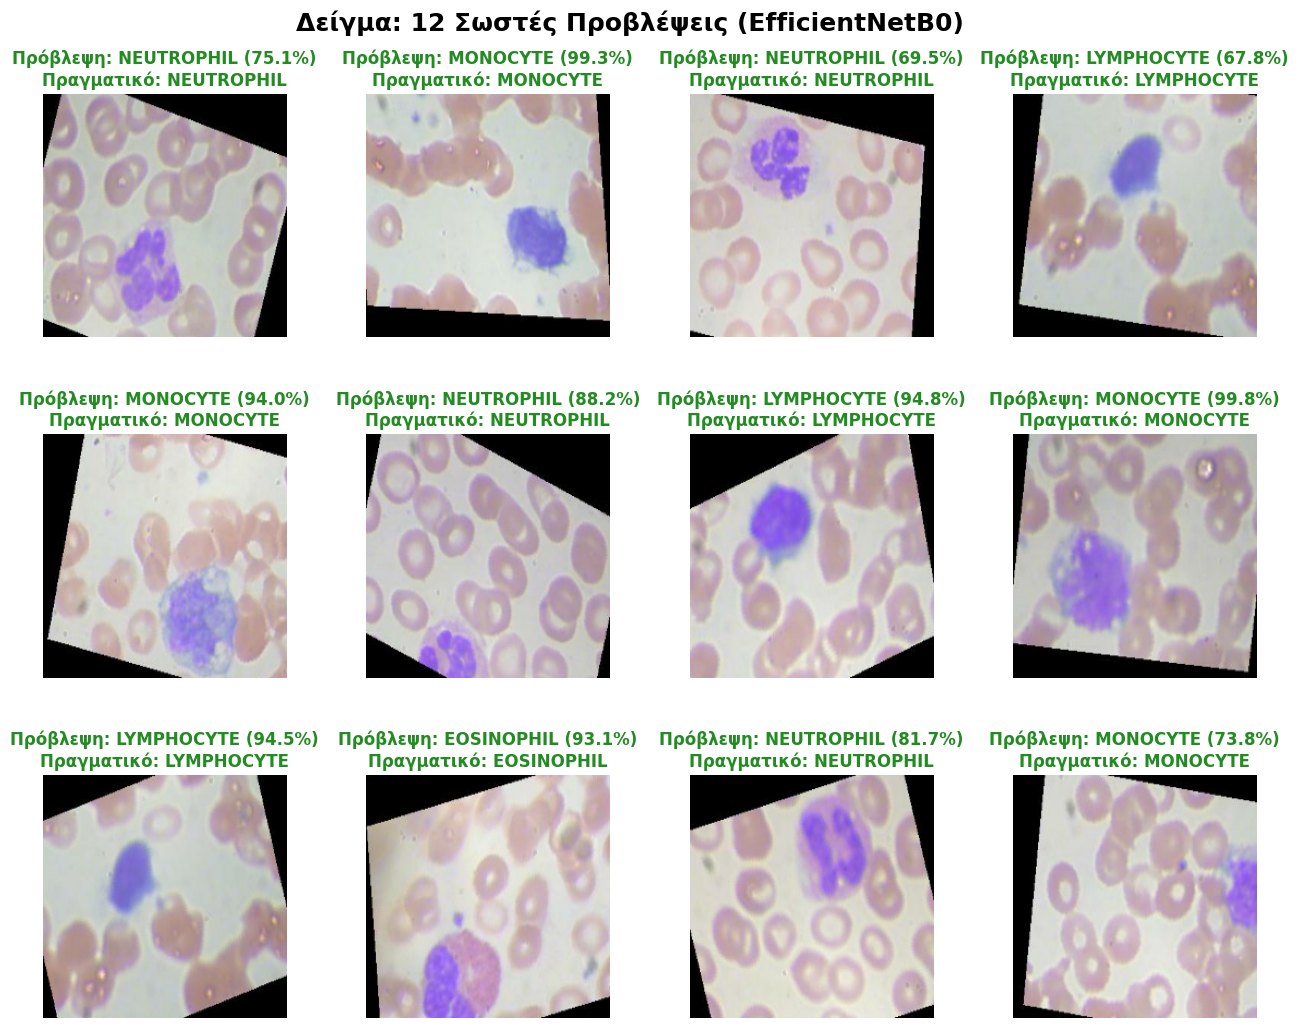

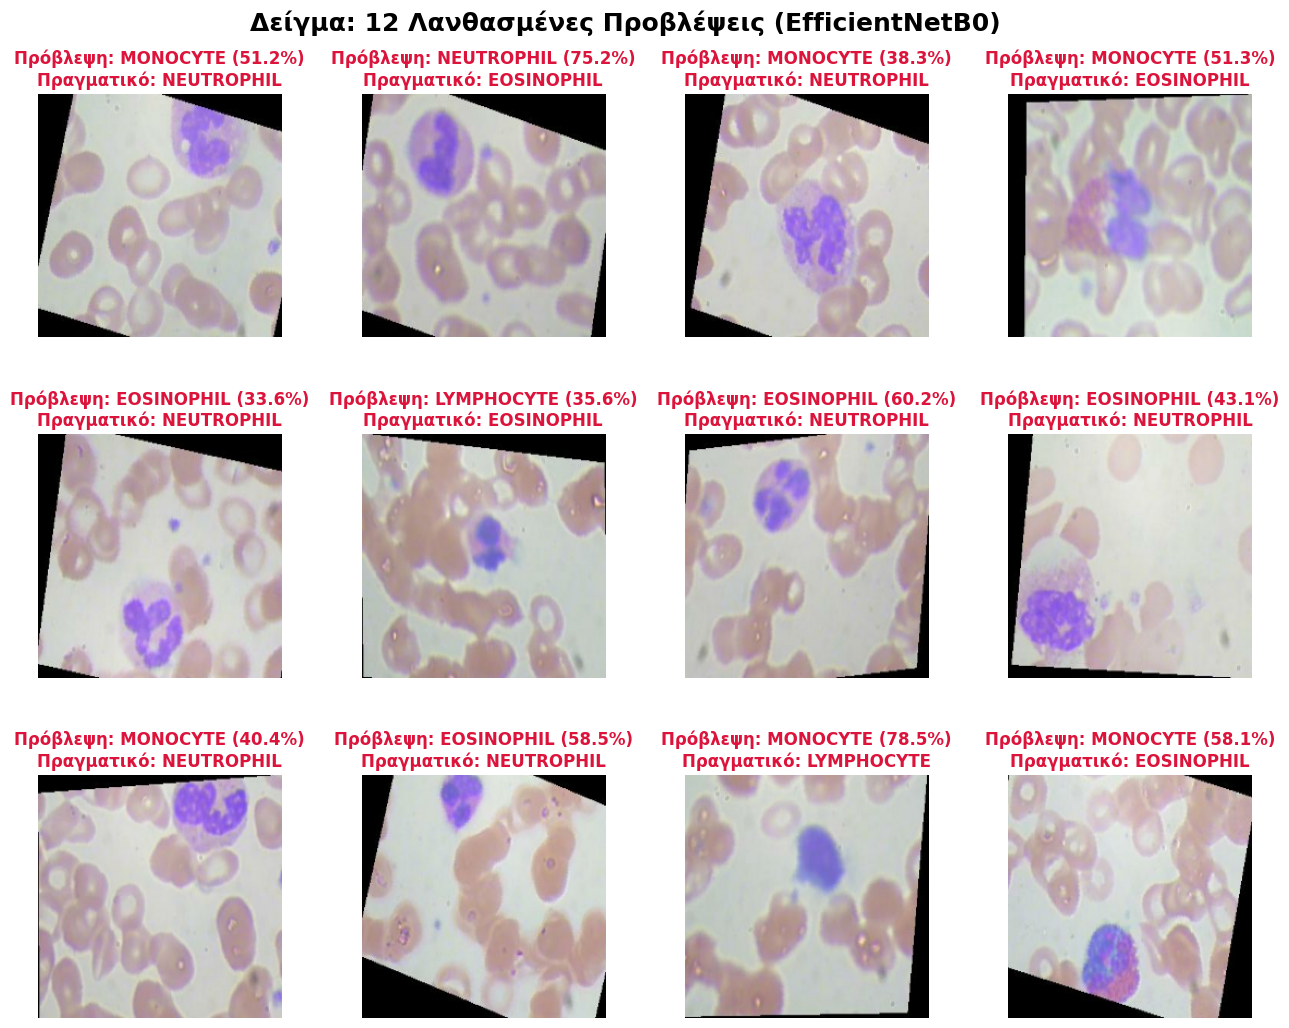

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names = sorted([d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))])

y_true_labels = []
y_pred_probs = []

for images, labels in val_ds:
    probs = final_eff.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true_labels.extend(np.argmax(labels.numpy(), axis=-1))

y_true_labels = np.array(y_true_labels)
y_pred_probs = np.array(y_pred_probs)

y_true_bin = label_binarize(y_true_labels, classes=[0, 1, 2, 3])
n_classes = 4

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'darkorange']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC - {class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Τυχαία Πρόβλεψη (Random)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ποσοστό Ψευδώς Θετικών (False Positive Rate)', fontsize=12)
plt.ylabel('Ποσοστό Αληθώς Θετικών (True Positive Rate)', fontsize=12)
plt.title('Καμπύλες ROC ανά Κλάση (EfficientNetB0 - Τελικό)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()


correct_imgs, correct_preds, correct_trues, correct_probs = [], [], [], []
error_imgs, error_preds, error_trues, error_probs = [], [], [], []

for images, labels in val_ds:
    probs = final_eff.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(labels.numpy(), axis=1)

    for i in range(len(preds)):

        if preds[i] == trues[i] and len(correct_imgs) < 12:
            correct_imgs.append(images[i].numpy().astype("uint8"))
            correct_preds.append(preds[i])
            correct_trues.append(trues[i])
            correct_probs.append(np.max(probs[i]))

        elif preds[i] != trues[i] and len(error_imgs) < 12:
            error_imgs.append(images[i].numpy().astype("uint8"))
            error_preds.append(preds[i])
            error_trues.append(trues[i])
            error_probs.append(np.max(probs[i]))

    if len(correct_imgs) >= 12 and len(error_imgs) >= 12:
        break


plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

for i in range(len(correct_imgs)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(correct_imgs[i])
    pred_name = class_names[correct_preds[i]]
    confidence = correct_probs[i] * 100
    title_text = f"Πρόβλεψη: {pred_name} ({confidence:.1f}%)\nΠραγματικό: {pred_name}"
    plt.title(title_text, color='forestgreen', fontsize=12, fontweight='bold')
    plt.axis("off")

plt.suptitle('Δείγμα: 12 Σωστές Προβλέψεις (EfficientNetB0)', fontsize=18, fontweight='bold', y=0.95)
plt.show()

if len(error_imgs) > 0:
    plt.figure(figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4)

    for i in range(len(error_imgs)):
        plt.subplot(3, 4, i + 1)
        plt.imshow(error_imgs[i])
        pred_name = class_names[error_preds[i]]
        true_name = class_names[error_trues[i]]
        confidence = error_probs[i] * 100
        title_text = f"Πρόβλεψη: {pred_name} ({confidence:.1f}%)\nΠραγματικό: {true_name}"
        plt.title(title_text, color='crimson', fontsize=12, fontweight='bold')
        plt.axis("off")

    plt.suptitle('Δείγμα: 12 Λανθασμένες Προβλέψεις (EfficientNetB0)', fontsize=18, fontweight='bold', y=0.95)
    plt.show()
else:
    print("Το μοντέλο δεν έκανε κανένα λάθος σε αυτό το δείγμα!")

### 15. Fine-Tuning

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

for layer in final_eff.layers:

    if isinstance(layer, tf.keras.Model):
        layer.trainable = True

FINE_TUNE_LR = 1e-5

final_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

FINE_TUNE_EPOCHS = 10

hist_fine_tune = final_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[fine_tune_stopper],
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_fine_tune.history['accuracy'], label='Εκπαίδευση', marker='o', color='#1f77b4')
plt.plot(hist_fine_tune.history['val_accuracy'], label='Επαλήθευση', marker='s', color='#ff7f0e')
plt.title('Fine-Tuning: Ακρίβεια', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές Fine-Tuning', fontsize=12)
plt.ylabel('Ακρίβεια', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_fine_tune.history['loss'], label='Εκπαίδευση (Train)', marker='o', color='#1f77b4')
plt.plot(hist_fine_tune.history['val_loss'], label='Επαλήθευση (Val)', marker='s', color='red')
plt.title('Fine-Tuning: Σφάλμα (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές Fine-Tuning', fontsize=12)
plt.ylabel('Σφάλμα', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


best_ft_acc = max(hist_fine_tune.history['val_accuracy']) * 100
print(f"\nΤελική Ακρίβεια Επαλήθευσης μετά το Fine-Tuning: {best_ft_acc:.2f}%")

### 16. Test


 [25% Δεδομένων] Εκπαίδευση με 62 πακέτα (batches)...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 220ms/step - accuracy: 0.3649 - loss: 1.3271 - val_accuracy: 0.5625 - val_loss: 1.1409
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.5066 - loss: 1.1552 - val_accuracy: 0.6339 - val_loss: 1.0262
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.5499 - loss: 1.0752 - val_accuracy: 0.6349 - val_loss: 0.9705
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.5993 - loss: 1.0099 - val_accuracy: 0.6931 - val_loss: 0.8974
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.5913 - loss: 0.9935 - val_accuracy: 0.7137 - val_loss: 0.8574

 [50% Δεδομένων] Εκπαίδευση με 124 πακέτα (batches)...
Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 28s 131ms/step - accuracy: 0.4204 - loss: 1.2564 - val_accuracy: 0.6047 - val_loss: 1.0447
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.5602

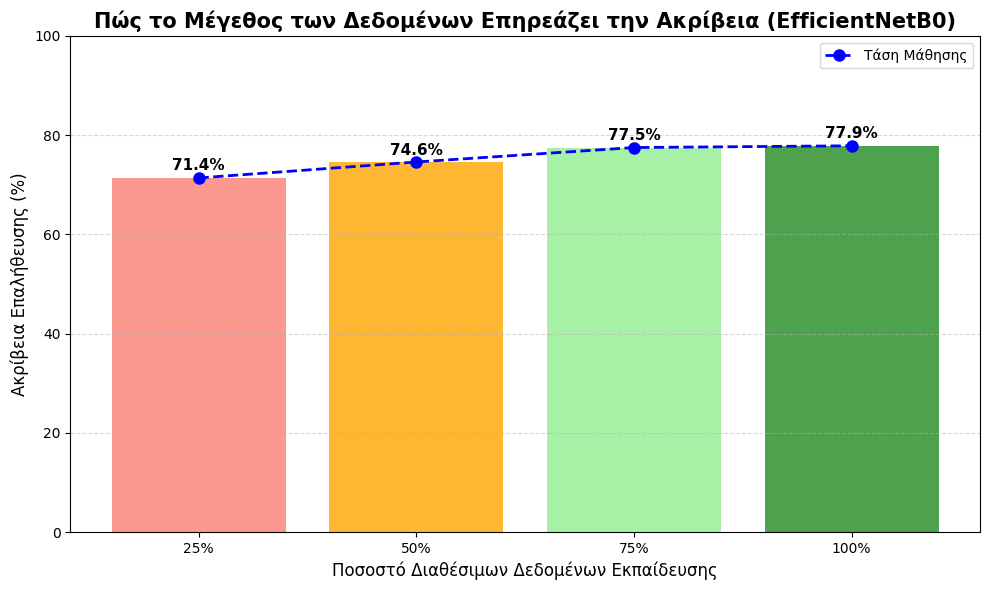

In [ ]:
 import tensorflow as tf
import matplotlib.pyplot as plt

percentages = [0.25, 0.50, 0.75, 1.0]
results_acc_data = []
total_batches = len(train_ds)

for p in percentages:
    tf.keras.backend.clear_session()
    batches_to_keep = int(total_batches * p)
    print(f"\n [{int(p*100)}% Δεδομένων] Εκπαίδευση με {batches_to_keep} πακέτα (batches)...")

    if p == 1.0:
        current_train_ds = train_ds
    else:
        current_train_ds = train_ds.take(batches_to_keep)

    model_data_test = build_efficientnet_model(learning_rate=0.001, dropout_rate=0.2, optimizer_choice='adam')
    history_data = model_data_test.fit(current_train_ds, validation_data=val_ds, epochs=5, verbose=1)

    best_acc = max(history_data.history['val_accuracy']) * 100
    results_acc_data.append(best_acc)

plt.figure(figsize=(10, 6))
labels = ['25%', '50%', '75%', '100%']
colors = ['salmon', 'orange', 'lightgreen', 'forestgreen']

bars = plt.bar(labels, results_acc_data, color=colors, alpha=0.8)
plt.plot(labels, results_acc_data, color='blue', marker='o', linestyle='dashed', linewidth=2, markersize=8, label='Τάση Μάθησης')

plt.title('Πώς το Μέγεθος των Δεδομένων Επηρεάζει την Ακρίβεια (EfficientNetB0)', fontsize=15, fontweight='bold')
plt.xlabel('Ποσοστό Διαθέσιμων Δεδομένων Εκπαίδευσης', fontsize=12)
plt.ylabel('Ακρίβεια Επαλήθευσης (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()